<a href="https://colab.research.google.com/github/kkumarisfdc/Kiran-s_Portfolio/blob/main/Day_21_Feature_Enginnering_of_gRNA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#install required packages
!pip -q install pandas

In [ ]:
import pandas as pd
import gzip
import shutil
import requests
import os

In [ ]:
# dbGuide humn guide dataset
url = "https://sgrnascorer.cancer.gov/downloads/hg_guide_info.csv.gz"

print("Downloading dataset ..." )
response = requests.get(url)
with open("hg_guide_info.csv.gz", "wb") as f:
    f.write(response.content)

print("Download Complete")




Download Complete


In [ ]:
#Unzip
with gzip.open('hg_guide_info.csv.gz', 'rb') as f_in:
    with open('hg_guide_info.csv', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
print("File Extracted")
df = pd.read_csv('hg_guide_info.csv')
print(df.head())
print(df.columns)

File Extracted
   AAAAAAAAAAAACTTACGGG  SpCas9  hg38   chr1   86124828   86124850  \
0  AAAAAAAAAAAAGTTACCTT  SpCas9  hg38   chr8   67057363   67057385   
1  AAAAAAAAAAACTTACCAAC  SpCas9  hg38  chr12  100050152  100050174   
2  AAAAAAAAAAAGCTAACAGC  SpCas9  hg38   chr4  151662744  151662766   
3  AAAAAAAAAAAGTCGTACTT  SpCas9  hg38   chr2  189133103  189133125   
4  AAAAAAAAAAAGTTACCTTT  SpCas9  hg38   chr8   67057364   67057386   

   0.927084195  0.6705        NV   25.96   True  \
0    -0.382642  0.3490        NV  25.210   True   
1    -0.297991  0.4294        NV  29.740   True   
2     0.009168  0.5290        NV  23.840   True   
3    -0.600016      NV  0.015387  23.329  False   
4    -0.643827  0.3276        NV  26.740   True   

                   ENST00000370571;ENST00000426639    3;3  Forecast  
0  ENST00000357849;ENST00000518747;ENST00000517736  4;4;4  Forecast  
1                  ENST00000279907;ENST00000545232  17;11  Forecast  
2                  ENST00000435205;ENST00000505

In [ ]:
import pandas as pd
df = pd.read_csv('hg_guide_info.csv', header=None)
print(df.head())
print(df.shape)

                     0       1     2      3          4          5         6   \
0  AAAAAAAAAAAACTTACGGG  SpCas9  hg38   chr1   86124828   86124850  0.927084   
1  AAAAAAAAAAAAGTTACCTT  SpCas9  hg38   chr8   67057363   67057385 -0.382642   
2  AAAAAAAAAAACTTACCAAC  SpCas9  hg38  chr12  100050152  100050174 -0.297991   
3  AAAAAAAAAAAGCTAACAGC  SpCas9  hg38   chr4  151662744  151662766  0.009168   
4  AAAAAAAAAAAGTCGTACTT  SpCas9  hg38   chr2  189133103  189133125 -0.600016   

       7         8       9      10  \
0  0.6705        NV  25.960   True   
1  0.3490        NV  25.210   True   
2  0.4294        NV  29.740   True   
3  0.5290        NV  23.840   True   
4      NV  0.015387  23.329  False   

                                                11     12        13  
0                  ENST00000370571;ENST00000426639    3;3  Forecast  
1  ENST00000357849;ENST00000518747;ENST00000517736  4;4;4  Forecast  
2                  ENST00000279907;ENST00000545232  17;11  Forecast  
3         

In [ ]:
df.columns =[
    "gRNA",
    "Cas",
    "Genome",
    "Chromosome",
    "Start",
    "End",
    "OnTargetScore",
    "OffTargetScore",
    "Efficiency",
    "ActivityScore",
    "Validated",
    "Transcript",
    "Exon",
    "Library"
]

In [ ]:
print(df.head())
print(df.info())

                   gRNA     Cas Genome Chromosome      Start        End  \
0  AAAAAAAAAAAACTTACGGG  SpCas9   hg38       chr1   86124828   86124850   
1  AAAAAAAAAAAAGTTACCTT  SpCas9   hg38       chr8   67057363   67057385   
2  AAAAAAAAAAACTTACCAAC  SpCas9   hg38      chr12  100050152  100050174   
3  AAAAAAAAAAAGCTAACAGC  SpCas9   hg38       chr4  151662744  151662766   
4  AAAAAAAAAAAGTCGTACTT  SpCas9   hg38       chr2  189133103  189133125   

   OnTargetScore OffTargetScore Efficiency  ActivityScore  Validated  \
0       0.927084         0.6705         NV         25.960       True   
1      -0.382642         0.3490         NV         25.210       True   
2      -0.297991         0.4294         NV         29.740       True   
3       0.009168         0.5290         NV         23.840       True   
4      -0.600016             NV   0.015387         23.329      False   

                                        Transcript   Exon   Library  
0                  ENST00000370571;ENST0000042

In [ ]:
#Keep only A,T,G,C
df["gRNA"]= df["gRNA"].astype(str).str.upper().str.strip()
df = df[df["gRNA"].str.fullmatch("[ATGC]+")]
#Keep guides of length 20
df = df[df["gRNA"].str.len()==20]
#Remove duplicates
df = df.drop_duplicates(subset=["gRNA"])
print("Number of unique guides:",len(df))

Number of unique guides: 3320547


In [ ]:
df = df.sample(n=1000,random_state=42)
df.reset_index(drop=True,inplace=True)
print(df.head())

                   gRNA     Cas Genome Chromosome      Start        End  \
0  ATTTAGCCTGATGAAAACAA  SpCas9   hg38       chr1  108944041  108944063   
1  TGCTCCCATGTCATCAACGT  SpCas9   hg38       chr1   64678284   64678306   
2  GTTATCCAGTGCCATAGAAC  SpCas9   hg38       chr3   50571215   50571237   
3  GTCCTTTCTGTCTATCCACC  SpCas9   hg38       chr5  175683680  175683702   
4  GTGGTGGGGTGAGGGGTGGT  SpCas9   hg38      chr19   55517802   55517824   

   OnTargetScore OffTargetScore Efficiency  ActivityScore  Validated  \
0      -0.314948         0.5333   0.143623          29.42       True   
1      -0.292637         0.6472   0.879929          36.73       True   
2      -0.141754         0.4756   0.599361          28.14       True   
3      -0.725096         0.3334   0.271694          42.58       True   
4       0.094325         0.3820         NV          42.87       True   

                                          Transcript       Exon  \
0                    ENST00000356970;ENST00000369

In [ ]:
df.to_csv("hg_guide_info_filtered.csv",index=False)
print("Saved Successfully.")

Saved Successfully.


In [ ]:
import pandas as pd
import numpy as np
import itertools


In [ ]:
#Dinucleotides (16)
dinucs=[''.join(x) for x in itertools.product('ATGC', repeat=2)]
#Trinucleotides (64)
trinucs =[''.join(x) for x in itertools.product('ATGC', repeat=3)]



In [ ]:
def extract_features(seq):
  features ={}
  seq_length = len(seq)

  #################################################################
  #  BASIC FEATURES
  ################################################################
  features["Length"] = seq_length
  A = seq.count("A")
  T = seq.count("T")
  G = seq.count("G")
  C = seq.count("C")

  features["A_Count"] = A
  features["T_Count"] = T
  features["G_Count"] = G
  features["C_Count"] = C

  features["A_Percent"] = A/seq_length
  features["T_Percent"] = T/seq_length
  features["G_Percent"] = G/seq_length
  features["C_Percent"] = C/seq_length

  features["GC_Content"] = (G+C)/seq_length
  features["AT_Content"] = (A+T)/seq_length

  #################################################################
  #  GC  SKEW
  ################################################################
  if (G+C) != 0:
    features["GC_SKEW"]= (G-C)/(G+C)
  else:
    features["GC_SKEW"] = 0

  if (A+T) != 0:
    features["AT_SKEW"]= (A-T)/(A+T)
  else:
    features["AT_SKEW"] = 0

  #################################################################
  #  DINUCLEOTITE COMPOSITION(16)
  ################################################################
  total_dinucs = seq_length-1
  for d in dinucs:
    features[d] = 0

  for i in range(total_dinucs):
    d  = seq[i:i+2]
    features[d] +=1

  for d in dinucs:
    if total_dinucs > 0:
      features[d]  /= total_dinucs
    else:
      features[d] = 0

  #################################################################
  #  TRINUCLEOTITE COMPOSITION (First 20)
  ################################################################
  total_trinucs = seq_length-2
  tri_counts ={}
  for tri in trinucs:
    tri_counts[tri] = 0

  for i in range(total_trinucs):
    tri  = seq[i:i+3]
    tri_counts[tri] +=1

  selected = trinucs[:20]

  for tri in selected:
    if total_trinucs > 0:
      features[tri]  = tri_counts[tri]/total_trinucs
    else:
      features[tri] = 0

  #################################################################
  #  POSITION FEATURES
  ################################################################

  for pos in range(5):
    nt = seq[pos]
    features[f"Pos_{pos+1}_A"] = int(nt=="A")
    features[f"Pos_{pos+1}_T"] = int(nt=="T")
    features[f"Pos_{pos+1}_G"] = int(nt=="G")
    features[f"Pos_{pos+1}_C"] = int(nt=="C")

  #################################################################
  #  GC CLAMP
  ################################################################
  # Ensure seq has enough characters for slicing
  if seq_length >= 5:
    end = seq[-5:]
    features["GC_CLAMP"] = end.count("G")+end.count("C")
  else:
    features["GC_CLAMP"] = 0 # Or handle as appropriate if sequence is too short

  #################################################################
  #  Longest  Homopolymer
  ################################################################

  longest = 1
  current = 1
  for i in range(1,seq_length):
    if seq[i]==seq[i-1]:
      current+=1
      longest = max(longest,current)
    else:
      current =1
  features["Longest_Run"] = longest

  #################################################################
  #  Shannon  Entropy
  ################################################################
  entropy = 0
  for nt in "ATGC":
    p  =seq.count(nt)/seq_length
    if p>0:
      entropy -= p*np.log2(p)
  features["Entropy"]=entropy

  #################################################################
  #  Purine  Ratio
  ################################################################
  features["Pyrimidine"] = (T+C)/seq_length
  return features


In [ ]:
features_list =[]
for seq in df["gRNA"]:
  features_list.append(extract_features(seq))

features_df = pd.DataFrame(features_list)

final_df  = pd.concat([df.reset_index(drop=True), features_df], axis=1)


print(final_df.head())
print(final_df.shape)

                   gRNA     Cas Genome Chromosome      Start        End  \
0  ATTTAGCCTGATGAAAACAA  SpCas9   hg38       chr1  108944041  108944063   
1  TGCTCCCATGTCATCAACGT  SpCas9   hg38       chr1   64678284   64678306   
2  GTTATCCAGTGCCATAGAAC  SpCas9   hg38       chr3   50571215   50571237   
3  GTCCTTTCTGTCTATCCACC  SpCas9   hg38       chr5  175683680  175683702   
4  GTGGTGGGGTGAGGGGTGGT  SpCas9   hg38      chr19   55517802   55517824   

   OnTargetScore OffTargetScore Efficiency  ActivityScore  ...  Pos_4_G  \
0      -0.314948         0.5333   0.143623          29.42  ...        0   
1      -0.292637         0.6472   0.879929          36.73  ...        0   
2      -0.141754         0.4756   0.599361          28.14  ...        0   
3      -0.725096         0.3334   0.271694          42.58  ...        0   
4       0.094325         0.3820         NV          42.87  ...        1   

  Pos_4_C Pos_5_A Pos_5_T  Pos_5_G  Pos_5_C  GC_CLAMP  Longest_Run   Entropy  \
0       0       1 

In [ ]:
final_df.to_csv("gRNA_84_Features.csv",index=False)
print("Feature matrix Saved Successfully...")



Feature matrix Saved Successfully...


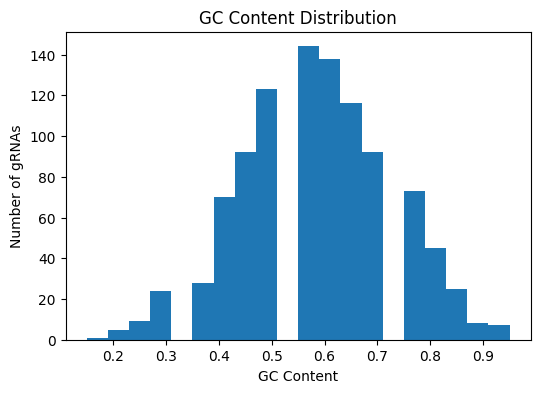

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.hist(final_df["GC_Content"],bins=20)
plt.xlabel("GC Content")
plt.ylabel("Number of gRNAs")
plt.title("GC Content Distribution")
plt.show()

In [ ]:
corr = final_df.select_dtypes(include=['number']).corr()
print(corr.head())

                  Start       End  OnTargetScore  ActivityScore  Length  \
Start          1.000000  1.000000      -0.040861      -0.003439     NaN   
End            1.000000  1.000000      -0.040861      -0.003439     NaN   
OnTargetScore -0.040861 -0.040861       1.000000       0.028731     NaN   
ActivityScore -0.003439 -0.003439       0.028731       1.000000     NaN   
Length              NaN       NaN            NaN            NaN     NaN   

                A_Count   T_Count   G_Count   C_Count  A_Percent  ...  \
Start          0.067603  0.090606 -0.078494 -0.065946   0.067603  ...   
End            0.067603  0.090606 -0.078494 -0.065946   0.067603  ...   
OnTargetScore -0.016431 -0.584540  0.438160  0.086943  -0.016431  ...   
ActivityScore -0.132472 -0.069760  0.136509  0.046636  -0.132472  ...   
Length              NaN       NaN       NaN       NaN        NaN  ...   

                Pos_4_G   Pos_4_C   Pos_5_A   Pos_5_T   Pos_5_G   Pos_5_C  \
Start         -0.039515  0.030455